In [364]:
import os

import torch
import torchsummary

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# for sklearn, we need to import sub-packages to access their functionality
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay, f1_score

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['figure.figsize'] = (12, 6)


In [365]:
df = pd.read_csv('../data/processed/FW_Veg_Rem_Combined_transformed.csv')
df.drop(columns=['Vegetation',"index"], inplace=True)

df.head()

,latitude,longitude,Temp_pre_30,Temp_pre_15,Temp_pre_7,Wind_pre_30,Wind_pre_15,Wind_pre_7,Hum_pre_30,Hum_pre_15,...,catastrophic,month_sin,month_cos,Vegetation_0,Vegetation_4,Vegetation_9,Vegetation_12,Vegetation_14,Vegetation_15,Vegetation_16
0,18.105072,-66.753044,24.480974,24.716923,24.902597,4.341807,3.492857,3.262092,78.216590,76.793750,...,1,8.660254e-01,0.500000,False,False,False,True,False,False,False
1,35.038330,-87.610000,7.553433,7.010000,0.343529,2.709764,2.881707,1.976471,70.840000,65.858911,...,0,-2.449294e-16,1.000000,False,False,False,False,False,True,False
2,34.947800,-88.722500,4.971930,5.782766,5.558750,3.364499,2.923830,2.695833,75.531629,75.868613,...,1,8.660254e-01,0.500000,False,False,False,False,False,False,True
3,39.641400,-119.308300,16.275967,18.996181,18.142564,4.054982,3.398329,3.671282,44.778429,37.140811,...,0,1.224647e-16,-1.000000,True,False,False,False,False,False,False
4,31.316978,-83.393649,14.877341,16.409326,17.175319,2.000214,1.727202,1.590696,79.896679,73.431818,...,0,5.000000e-01,0.866025,False,False,False,True,False,False,False


Dataset shape: (37208, 24)


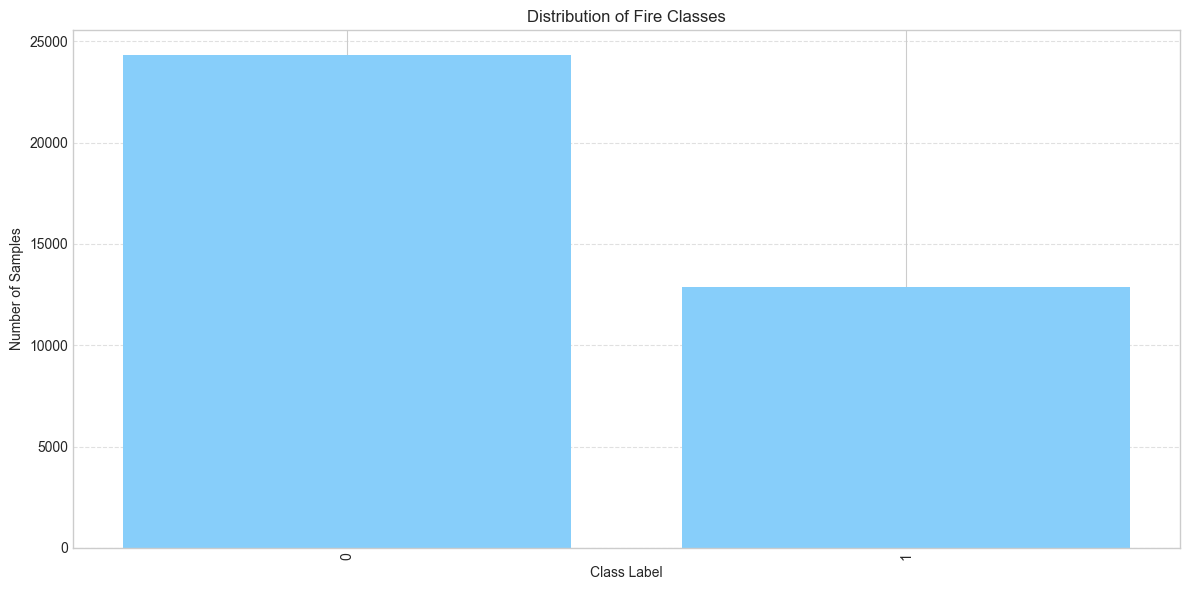

In [366]:
# Use all but the last column as input
inputs = df.drop("catastrophic", axis=1, inplace=False).to_numpy()
# Use the "character" column as our labels
targets = df["catastrophic"].to_numpy()

# Count the occurrences of each label
unique_labels, counts = np.unique(targets, return_counts=True)

# Display dataset information
print(f"Dataset shape: {inputs.shape}")

# Check distribution of characters
plt.bar(unique_labels, counts, width=0.8,color='#87CEFA')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.title('Distribution of Fire Classes')
plt.xticks(unique_labels,rotation=90)  # Show all labels on x-axis
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [367]:
# First split: 80% train+validation, 20% test
X_train_val, X_test, T_train_val, T_test = train_test_split(inputs, targets, test_size=0.2, random_state=42, stratify=targets)

# Second split: 80% train, 20% test (resulting in 64%/16%/20% overall)
X_train, X_val, T_train, T_val = train_test_split(X_train_val, T_train_val, test_size=0.2, random_state=42, stratify=T_train_val)

scaler = StandardScaler()
# Fit the scaler on the training data
scaler.fit(X_train)
# Transform the training, validation, and test data
X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Display the shapes of the resulting datasets
print(f"Training set: {X_train.shape}, {T_train.shape}")
print(f"Validation set: {X_val.shape}, {T_val.shape}")
print(f"Test set: {X_test.shape}, {T_test.shape}")

Training set: (23812, 24), (23812,)
Validation set: (5954, 24), (5954,)
Test set: (7442, 24), (7442,)


In [368]:
# Build custom dataset
class WildfireDataset(torch.utils.data.Dataset):
    def __init__(self, X, T, transform=None):

        # Convert to tensors if needed
        if not isinstance(X, torch.Tensor):
            X = torch.tensor(X, dtype=torch.float32)

        # Store inputs
        self.inputs = X

        # Encode string labels to integer class indices
        unique_labels = sorted(set(T))
        self.label2index = {label: idx for idx, label in enumerate(unique_labels)}
        # Store encoded targets
        self.targets = torch.tensor([self.label2index[label] for label in T], dtype=torch.float32)


        # Store transform
        self.transform = transform


    def __getitem__(self, index):
        # get input and target for the given index
        input = self.inputs[index]
        target = self.targets[index]

        # Apply optional transform (e.g., normalization)
        if self.transform:
            input = self.transform(input)

        # return both the input sample and its target class
        return input, target


    def __len__(self):
        # return the number of samples in our dataset
        return len(self.inputs)


# Create Dataset objects for all sets
train_dataset = WildfireDataset(X_train ,T_train)
val_dataset = WildfireDataset(X_val, T_val)
test_dataset = WildfireDataset(X_test, T_test)

batch_size = 128  # You can change this as needed

# Create DataLoaders for the three datasets.
# Here, we only set shuffle to true for the training loader
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [369]:
class WildfireNet(torch.nn.Module):
    def __init__(self, input_size, K1, K2, dropout_p):
        # Call base class constructor
        super(WildfireNet, self).__init__()

        # Define layers explicitly using torch.nn
        self.fc1 = torch.nn.Linear(input_size, K1)
        self.fc2 = torch.nn.Linear(K1, K2)
        self.fc3 = torch.nn.Linear(K2, 1)

        # We want a batchnorm after the second layer
        self.batchnorm = torch.nn.BatchNorm1d(K2)

        # And a dropout
        self.dropout = torch.nn.Dropout(dropout_p, inplace=False)

    def forward(self, x):

        if x.ndim > 2:
            x = torch.flatten(x, start_dim=1)  # Flatten if needed

        x = torch.nn.functional.relu(self.fc1(x))
        x = torch.nn.functional.relu(self.batchnorm(self.fc2(x)))
        x = self.dropout(x)
        z = self.fc3(x)

        return z

In [370]:
# Create model
model = WildfireNet(input_size=24, K1=64, K2=32, dropout_p=0.5)

print(model)

WildfireNet(
  (fc1): Linear(in_features=24, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (batchnorm): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [ ]:
# Summary of the model including forward pass
model_summary = torchsummary.summary(model, input_size=(24,),device="cpu")
print(model_summary)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 64]           1,600
            Linear-2                   [-1, 32]           2,080
       BatchNorm1d-3                   [-1, 32]              64
           Dropout-4                   [-1, 32]               0
            Linear-5                    [-1, 1]              33
Total params: 3,777
Trainable params: 3,777
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.02
----------------------------------------------------------------


In [372]:
# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the loss function
weight = np.sum(T_train == 0) / np.sum(T_train == 1)
pos_weight = torch.tensor([weight])
loss_function = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Define the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01,weight_decay=1e-4)

# Define the LRScheduler
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.1, patience=2, min_lr=1e-5)

In [373]:
num_epochs = 60
model.to(device)

train_loss_list, train_acc_list = [], []
val_loss_list, val_acc_list = [], []

for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct = 0, 0
    current_lr = optimizer.param_groups[0]['lr']

    for x, t in train_loader:
        optimizer.zero_grad()
        x, t = x.to(device), t.to(device)
        z = model(x)
        J = loss_function(z.squeeze(1), t)
        J.backward()
        optimizer.step()
        train_loss += J.item() * len(t)
        preds = (z.squeeze(1) >= 0.5).float()
        train_correct += (preds == t).sum().item()

    avg_train_loss = train_loss / len(train_dataset)
    train_acc = train_correct / len(train_dataset)
    train_loss_list.append(avg_train_loss)
    train_acc_list.append(train_acc)

    # --- Validation ---
    model.eval()
    val_loss, val_correct = 0, 0
    all_val_preds = []
    all_val_targets = []

    with torch.no_grad():
        for x, t in val_loader:
            x, t = x.to(device), t.to(device)
            z = model(x)
            J = loss_function(z.squeeze(1), t)
            val_loss += J.item() * len(t)
            probs = torch.sigmoid(z.squeeze(1))
            preds = (probs >= 0.5).float()
            val_correct += (preds == t).sum().item()
            all_val_preds.extend(preds.cpu().numpy())
            all_val_targets.extend(t.cpu().numpy())

    avg_val_loss = val_loss / len(val_dataset)
    val_acc = val_correct / len(val_dataset)
    val_loss_list.append(avg_val_loss)
    val_acc_list.append(val_acc)

    # --- Compute F1 score ---
    val_f1 = f1_score(all_val_targets, all_val_preds)
    # --- Compute Positive Recall ---
    all_val_targets = np.array(all_val_targets).astype(int)
    all_val_preds = np.array(all_val_preds).astype(int)

    if np.sum(all_val_targets == 1) > 0:
        val_recall = np.sum((all_val_targets == 1) & (all_val_preds == 1)) / np.sum(all_val_targets == 1)
    else:
        val_recall = 0.0


    # --- Scheduler step based on Positive Recall ---
    lr_scheduler.step(val_recall)

    # --- Logging ---
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"LR: {current_lr:.5f} | "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f} | Val Recall: {val_recall:.4f}")


Epoch 1/60 | LR: 0.01000 | Train Loss: 0.7975 | Train Acc: 0.7172 | Val Loss: 0.7530 | Val Acc: 0.7214 | Val F1: 0.5288 | Val Recall: 0.4517
Epoch 2/60 | LR: 0.01000 | Train Loss: 0.7682 | Train Acc: 0.7355 | Val Loss: 0.7493 | Val Acc: 0.7365 | Val F1: 0.4989 | Val Recall: 0.3789
Epoch 3/60 | LR: 0.01000 | Train Loss: 0.7571 | Train Acc: 0.7401 | Val Loss: 0.7412 | Val Acc: 0.7269 | Val F1: 0.5273 | Val Recall: 0.4401
Epoch 4/60 | LR: 0.01000 | Train Loss: 0.7574 | Train Acc: 0.7388 | Val Loss: 0.7409 | Val Acc: 0.7136 | Val F1: 0.5632 | Val Recall: 0.5332
Epoch 5/60 | LR: 0.01000 | Train Loss: 0.7550 | Train Acc: 0.7418 | Val Loss: 0.7359 | Val Acc: 0.7314 | Val F1: 0.5464 | Val Recall: 0.4672
Epoch 6/60 | LR: 0.01000 | Train Loss: 0.7504 | Train Acc: 0.7426 | Val Loss: 0.7369 | Val Acc: 0.7445 | Val F1: 0.5313 | Val Recall: 0.4182
Epoch 7/60 | LR: 0.01000 | Train Loss: 0.7486 | Train Acc: 0.7433 | Val Loss: 0.7392 | Val Acc: 0.7188 | Val F1: 0.5347 | Val Recall: 0.4668
Epoch 8/60 | 

Test Accuracy: 0.7308

Classification Report:
                  precision    recall  f1-score   support

Not Catastrophic       0.76      0.87      0.81      3893
    Catastrophic       0.66      0.47      0.55      2061

        accuracy                           0.73      5954
       macro avg       0.71      0.67      0.68      5954
    weighted avg       0.72      0.73      0.72      5954



<Figure size 600x600 with 0 Axes>

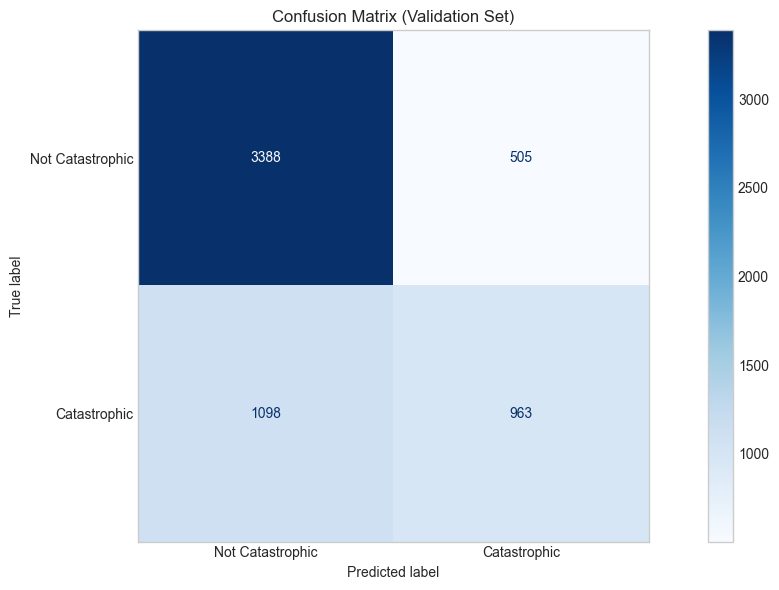

In [386]:
# --- Final Evaluation on Validation Set ---
model.eval()
all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for x, t in val_loader:
        x, t = x.to(device), t.to(device)
        z = model(x)
        probabilities = torch.sigmoid(z.squeeze(1))
        # Threshold at 0.5 to get predicted classes (0 or 1)
        preds = (probabilities >= 0.5).int()
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probabilities.cpu().numpy())
        all_labels.extend(t.cpu().numpy())
        
# Convert all lists to torch tensors
test_predictions = torch.tensor(all_preds)
test_probabilities = torch.tensor(all_probs)
test_labels = torch.tensor(all_labels)

# --- Accuracy ---
test_accuracy = accuracy_score(test_labels, test_predictions)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(test_labels, test_predictions, target_names=["Not Catastrophic", "Catastrophic"]))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Catastrophic", "Catastrophic"])

plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix (Validation Set)")
plt.grid(False)
plt.tight_layout()
plt.savefig(f'../reports/figures/confusion_matrix_val_nn.png')
plt.show()

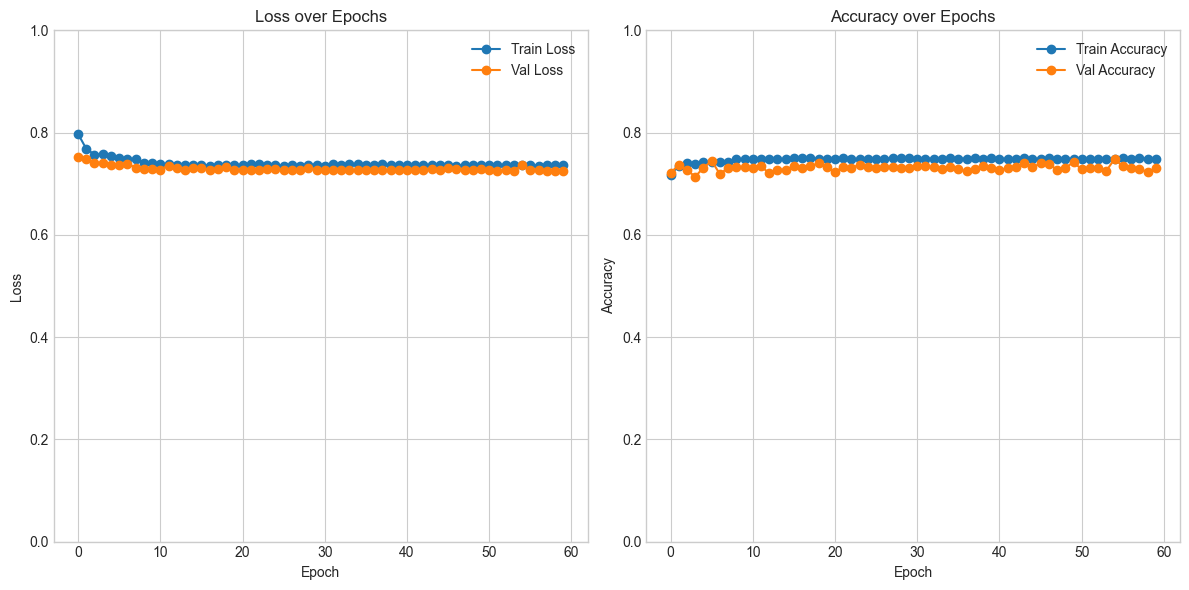

In [387]:
# --- Loss plot ---
plt.subplot(1, 2, 1)
plt.plot(train_loss_list, label="Train Loss", marker='o')
plt.plot(val_loss_list, label="Val Loss", marker='o')
# Set y range to [0, 1]
plt.ylim(0, 1)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()
plt.grid(True)

# --- Accuracy plot ---
plt.subplot(1, 2, 2)
plt.plot(train_acc_list, label="Train Accuracy", marker='o')
plt.plot(val_acc_list, label="Val Accuracy", marker='o')
# Set y range to [0, 1]
plt.ylim(0, 1)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(f'../reports/figures/network_epochs.png')

plt.show()

Test Accuracy: 0.7304

Classification Report:
                  precision    recall  f1-score   support

Not Catastrophic       0.76      0.86      0.81      4865
    Catastrophic       0.65      0.48      0.55      2577

        accuracy                           0.73      7442
       macro avg       0.70      0.67      0.68      7442
    weighted avg       0.72      0.73      0.72      7442



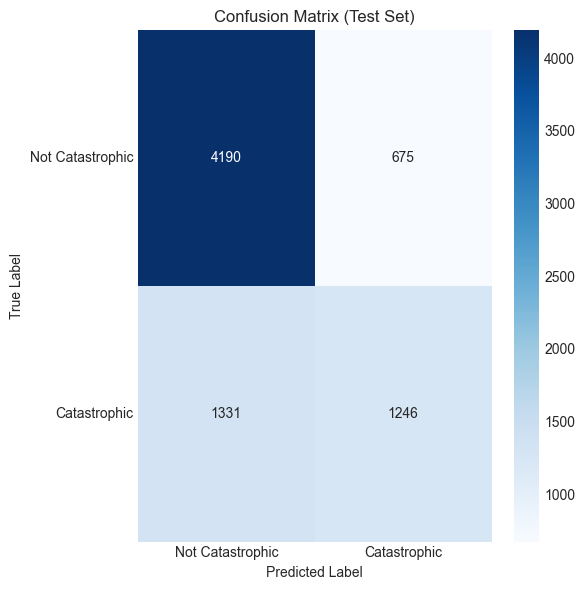

In [ ]:
# --- Final Evaluation on Test Set ---

# Set model to evaluation mode
model.eval()

# Store predictions
test_predictions, test_probabilities, test_labels = [], [], []

# Disable gradient calculation for efficiency
with torch.no_grad():
    for x, t in test_loader:
        x = x.to(device)
        z = model(x)
        probabilities = torch.sigmoid(z.squeeze(1))
        # Threshold at 0.5 to get predicted classes (0 or 1)
        predicted_classes = (probabilities >= 0.5).int()

        # Move data to CPU
        test_predictions.extend(predicted_classes.cpu())
        test_probabilities.extend(probabilities.cpu())
        test_labels.extend(t)

# Convert all lists to torch tensors
test_predictions = torch.tensor(test_predictions)
test_probabilities = torch.tensor(test_probabilities)
test_labels = torch.tensor(test_labels)

# --- Accuracy ---
test_accuracy = accuracy_score(test_labels, test_predictions)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(test_labels, test_predictions, target_names=["Not Catastrophic", "Catastrophic"]))


# --- Confusion Matrix ---
cm = confusion_matrix(test_labels, test_predictions)
class_names = ["Not Catastrophic", "Catastrophic"]  # Adjust to your labels
plt.figure(figsize=(6, 6))
sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)

plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(f'../reports/figures/confusion_matrix_test_nn.png')
plt.show()

#### Saving the Model for Comparison

In [380]:
model_path = os.path.abspath(os.path.join(os.getcwd(), "..", "models/neural_net.pth"))

torch.save(model.state_dict(), model_path)

We also save the test dataset.

In [381]:
# Saving the test dataset with pickling
dataset_path = os.path.abspath(os.path.join(os.getcwd(), "..", "data/interim/neuralNet_test_dataset.pth"))
torch.save(test_dataset, dataset_path)